# Fraud Detection in Electricity and Gas Consumption Challenge

## Import Libraries

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, precision_score, precision_recall_curve, fbeta_score

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier


## Download and extract files

In [2]:
client_train = pd.read_csv('data/train/client_train.csv', low_memory=False)

In [3]:
invoice_train = pd.read_csv('data/train/invoice_train.csv', low_memory=False)

In [4]:
client_test = pd.read_csv('data/test/client_test.csv', low_memory=False)

In [5]:
invoice_test = pd.read_csv('data/test/invoice_test.csv', low_memory=False)

# Data Prep

## Data Understanding

In [6]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_train.shape)

(135493, 6) (4476749, 16) (58069, 5) (4476749, 16)


In [7]:
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [8]:
client_test.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
dtype: int64

In [9]:
client_train.target.unique()

array([0., 1.])

In [10]:
invoice_train.describe().T

,count,mean,std,min,25%,50%,75%,max
tarif_type,4476749.0,2.012804e+01,1.347256e+01,8.0,11.0,11.0,40.0,4.500000e+01
counter_number,4476749.0,1.230587e+11,1.657267e+12,0.0,121108.0,494561.0,1115161.0,2.798115e+13
counter_code,4476749.0,1.724884e+02,1.338871e+02,0.0,5.0,203.0,207.0,6.000000e+02
reading_remarque,4476749.0,7.321702e+00,1.571654e+00,5.0,6.0,8.0,9.0,4.130000e+02
counter_coefficient,4476749.0,1.003040e+00,3.083466e-01,0.0,1.0,1.0,1.0,5.000000e+01
consommation_level_1,4476749.0,4.109795e+02,7.573080e+02,0.0,79.0,274.0,600.0,9.999100e+05
consommation_level_2,4476749.0,1.093225e+02,1.220123e+03,0.0,0.0,0.0,0.0,9.990730e+05
consommation_level_3,4476749.0,2.030620e+01,1.574239e+02,0.0,0.0,0.0,0.0,6.449200e+04
consommation_level_4,4476749.0,5.292588e+01,8.754725e+02,0.0,0.0,0.0,0.0,5.479460e+05
old_index,4476749.0,1.776700e+04,4.036693e+04,0.0,1791.0,7690.0,21660.0,2.800280e+06


In [11]:
counter_stats = invoice_train.groupby('counter_type')[
    ['consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4']
].agg(['mean', 'max', 'std'])

print(counter_stats.T)

counter_type                        ELEC            GAZ
consommation_level_1 mean     507.918803     197.348707
                     max    99920.000000  999910.000000
                     std      597.984711     991.476389
consommation_level_2 mean     158.122399       1.779250
                     max   999073.000000   29806.000000
                     std     1466.627210     111.135413
consommation_level_3 mean      29.520556       0.000000
                     max    64492.000000       0.000000
                     std      189.091928       0.000000
consommation_level_4 mean      76.942075       0.000000
                     max   547946.000000       0.000000
                     std     1054.702565       0.000000


In [12]:
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [13]:
invoice_train.counter_coefficient.value_counts()

counter_coefficient
1     4475102
2         886
3         321
40        197
30        137
0          46
6          30
4          12
10          6
20          3
9           3
50          2
33          1
5           1
11          1
8           1
Name: count, dtype: int64

In [14]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [15]:
client_train.disrict.unique()

array([60, 69, 62, 63], dtype=int64)

No missing values in train set

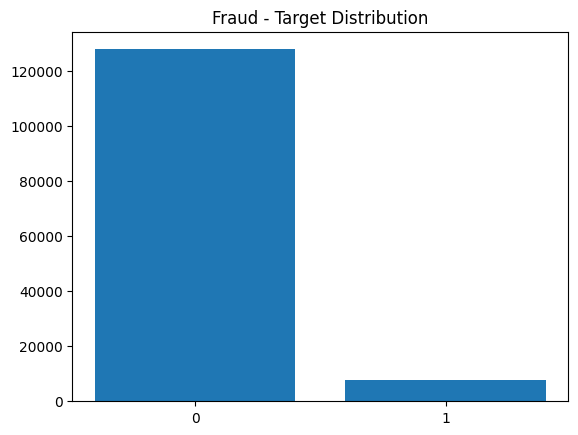

In [16]:
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

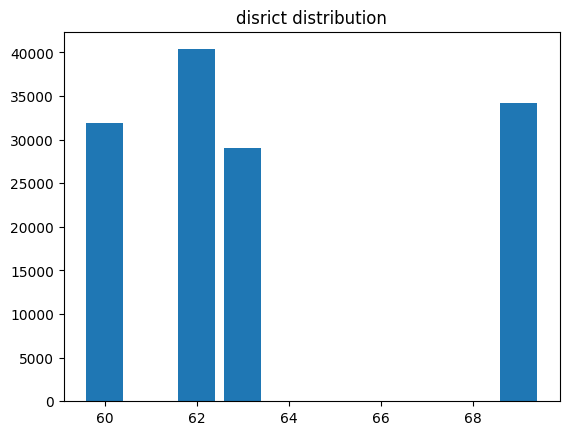

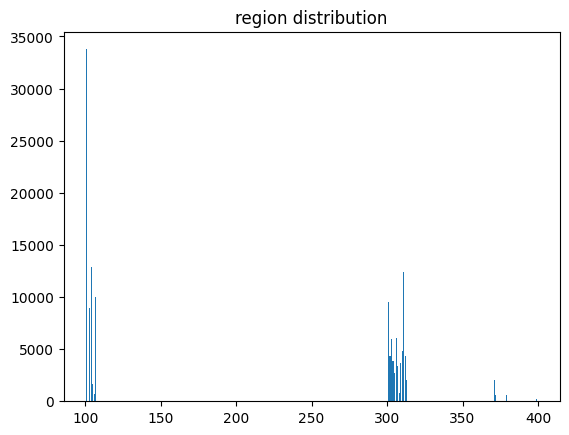

In [17]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

## Feature Engineering

In [18]:
#convert the column invoice_date to date time format on both the invoice train and invoice test
for df in [invoice_train,invoice_test]:
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

In [19]:
#encode labels in categorical column
d={"ELEC":0,"GAZ":1}
invoice_train['counter_type']=invoice_train['counter_type'].map(d)
invoice_test['counter_type']=invoice_test['counter_type'].map(d)

In [20]:
#convert categorical columns to int for model
client_train['client_catg'] = client_train['client_catg'].astype(int)
client_train['disrict'] = client_train['disrict'].astype(int)

client_test['client_catg'] = client_test['client_catg'].astype(int)
client_test['disrict'] = client_test['disrict'].astype(int)

### Manual Aggreagation

In [21]:
# find consumption levels and amounts for each clients
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = [''.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [22]:
agg_train = aggregate_by_client_id(invoice_train)

print(agg_train.shape)
agg_train.head()

(135493, 22)


,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3mean,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,0.000000,0,0,0.000000,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,117.357143,800,0,289.433294,1643,36.714286,382,0,105.421081,514


In [23]:
# calculate the consumption from the counter's index
invoice_train['calc_index'] = invoice_train['new_index'] - invoice_train['old_index']

In [24]:
# aggregate each invoice's index for each client
calc_index_sum = invoice_train.groupby('client_id')['calc_index'].sum()

agg_train_index = pd.merge(agg_train, calc_index_sum, on='client_id', how='left')

agg_train_index.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3max,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,12704
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,20629
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,15057
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0,0.000000,0,0.000000,0,0,0.000000,0,24
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,800,0,289.433294,1643,36.714286,382,0,105.421081,514,12917


In [25]:
# we want to know the last tarif the client uses to interpret the consumption levels
calc_tarif_type = invoice_train.groupby('client_id')['tarif_type'].last()

agg_train_tarif = pd.merge(agg_train_index, calc_tarif_type, on='client_id', how='left')

In [26]:
agg_train_tarif.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3min,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,12704,11
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,20629,11
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,15057,11
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0,0.000000,0,0.000000,0,0,0.000000,0,24,11
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,0,289.433294,1643,36.714286,382,0,105.421081,514,12917,11


In [27]:
## we want to know the counter coefficienct of the client uses to interpret the consumption levels

calc_counter_coeff = invoice_train.groupby('client_id')['counter_coefficient'].last()

agg_train_coeff = pd.merge(agg_train_tarif, calc_counter_coeff, on='client_id', how='left')

In [28]:
agg_train_coeff.head()

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_3std,consommation_level_3sum,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0.000000,0,0,0.000000,0,12704,11,1
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,20629,11,1
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0.000000,0,0,0.000000,0,15057,11,1
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0.000000,0,0,0.000000,0,24,11,1
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,289.433294,1643,36.714286,382,0,105.421081,514,12917,11,1


In [29]:
agg_train_coeff.counter_coefficient.value_counts()

counter_coefficient
1     135455
2         20
3          9
40         2
6          2
50         1
20         1
30         1
4          1
0          1
Name: count, dtype: int64

In [30]:
energy_features = (
    invoice_train
    .groupby('client_id')['counter_type']
    .agg(
        has_electricity=lambda x: int((x == 0).any()),
        has_gas=lambda x: int((x == 1).any())
    )
    .reset_index()
)

In [31]:
energy_features

,client_id,has_electricity,has_gas
0,train_Client_0,1,0
1,train_Client_1,1,0
2,train_Client_10,1,0
3,train_Client_100,1,0
4,train_Client_1000,1,0
...,...,...,...
135488,train_Client_99995,1,1
135489,train_Client_99996,1,1
135490,train_Client_99997,1,1
135491,train_Client_99998,1,0


In [32]:
agg_train_all = pd.merge(agg_train_coeff, energy_features, on='client_id', how='left')
agg_train_all

,client_id,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,consommation_level_1std,consommation_level_1sum,consommation_level_2mean,consommation_level_2max,consommation_level_2min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,train_Client_0,35,352.400000,1200,38,310.343472,12334,10.571429,186,0,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,train_Client_1,37,557.540541,1207,190,197.935960,20629,0.000000,0,0,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,train_Client_10,18,798.611111,2400,188,513.841374,14375,37.888889,682,0,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,train_Client_100,20,1.200000,15,0,3.607011,24,0.000000,0,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,train_Client_1000,14,663.714286,800,124,224.831365,9292,104.857143,400,0,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,train_Client_99995,71,1.957746,139,0,16.496265,139,0.000000,0,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,train_Client_99996,41,185.853659,800,0,200.935258,7620,0.756098,31,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,train_Client_99997,36,273.083333,1075,33,211.123441,9831,0.000000,0,0,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,train_Client_99998,2,300.000000,400,200,141.421356,600,70.500000,135,6,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [33]:
aggregated_manually = pd.merge(client_train,agg_train_all, on='client_id', how='left')

In [34]:
aggregated_manually

,disrict,client_id,client_catg,region,creation_date,target,1transactions_count,consommation_level_1mean,consommation_level_1max,consommation_level_1min,...,consommation_level_4mean,consommation_level_4max,consommation_level_4min,consommation_level_4std,consommation_level_4sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,1,1,0


### Aggregation Function

In [27]:
def agg_merged_datasets(client, invoice):

    # aggregation consumption levels
    aggs = {}
    aggs['consommation_level_1'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_2'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_3'] = ['mean', 'max', 'min', 'std', 'sum']
    aggs['consommation_level_4'] = ['mean', 'max', 'min', 'std', 'sum']

    agg_trans = invoice.groupby('client_id').agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    # number of transactions per client
    df = (
        invoice.groupby('client_id')
        .size()
        .reset_index(name='transactions_count')
    )

    agg_data = pd.merge(df, agg_trans, on='client_id', how='left')

    # calc_index feature
    invoice['calc_index'] = invoice['new_index'] - invoice['old_index']

    calc_index_sum = (
        invoice.groupby('client_id')['calc_index']
        .sum()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_index_sum, on='client_id', how='left')

    # tarif type
    calc_tarif_type = (
        invoice.groupby('client_id')['tarif_type']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_tarif_type, on='client_id', how='left')

    # counter coefficient
    calc_counter_coeff = (
        invoice.groupby('client_id')['counter_coefficient']
        .last()
        .reset_index()
    )

    agg_data = pd.merge(agg_data, calc_counter_coeff, on='client_id', how='left')

    # electricity / gas features
    energy_features = (
        invoice
        .groupby('client_id')['counter_type']
        .agg(
            has_electricity=lambda x: int((x == 0).any()),
            has_gas=lambda x: int((x == 1).any())
        )
        .reset_index()
    )

    agg_data = pd.merge(agg_data, energy_features, on='client_id', how='left')

    # merge with client table
    final_df = pd.merge(client, agg_data, on='client_id', how='left')

    return final_df

In [28]:
train_combined = agg_merged_datasets(client_train, invoice_train)

In [29]:
train_combined.shape

(135493, 32)

In [30]:
test_combined = agg_merged_datasets(client_test, invoice_test)

In [31]:
test_combined.shape

(58069, 31)

In [32]:
train_combined 

,disrict,client_id,client_catg,region,creation_date,target,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,train_Client_0,11,101,31/12/1994,0.0,35,352.400000,1200,38,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,train_Client_1,11,107,29/05/2002,0.0,37,557.540541,1207,190,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,train_Client_10,11,301,13/03/1986,0.0,18,798.611111,2400,188,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,train_Client_100,11,105,11/07/1996,0.0,20,1.200000,15,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,train_Client_1000,11,303,14/10/2014,0.0,14,663.714286,800,124,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,train_Client_99995,11,304,26/07/2004,0.0,71,1.957746,139,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,train_Client_99996,11,311,25/10/2012,0.0,41,185.853659,800,0,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,train_Client_99997,11,311,22/11/2011,0.0,36,273.083333,1075,33,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,train_Client_99998,11,101,22/12/1993,0.0,2,300.000000,400,200,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [33]:
test_combined

,disrict,client_id,client_catg,region,creation_date,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,62,test_Client_0,11,307,28/05/2002,37,488.135135,1090,0,230.388942,...,0.000000,0,0,0.000000,0,18181,11,1,1,0
1,69,test_Client_1,11,103,06/08/2009,22,1091.409091,3600,11,739.185437,...,586.318182,12899,0,2750.076040,12899,59470,11,1,1,0
2,62,test_Client_10,11,310,07/04/2004,74,554.040541,1200,0,346.775891,...,0.162162,12,0,1.394972,12,44941,40,1,1,1
3,60,test_Client_100,11,101,08/10/1992,40,244.350000,721,0,247.253171,...,0.000000,0,0,0.000000,0,9774,11,1,1,1
4,62,test_Client_1000,11,301,21/07/1977,53,568.188679,2400,0,486.891871,...,0.000000,0,0,0.000000,0,39703,11,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,63,test_Client_9995,11,399,17/03/2010,4,461.250000,938,0,532.755964,...,0.000000,0,0,0.000000,0,1845,11,1,1,1
58065,63,test_Client_9996,11,311,28/05/2011,46,181.565217,456,0,107.556838,...,0.000000,0,0,0.000000,0,8352,40,1,1,1
58066,60,test_Client_9997,11,101,04/03/1978,59,160.559322,739,22,104.969334,...,0.000000,0,0,0.000000,0,10177,10,1,1,1
58067,60,test_Client_9998,11,101,23/02/2018,1,800.000000,800,800,NaN,...,0.000000,0,0,NaN,0,1927,11,1,1,0


In [34]:
X_train = train_combined.drop(columns=['client_id', 'creation_date', 'target', 'region'])
X_train

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,60,11,35,352.400000,1200,38,310.343472,12334,10.571429,186,...,0.000000,0,0,0.000000,0,12704,11,1,1,0
1,69,11,37,557.540541,1207,190,197.935960,20629,0.000000,0,...,0.000000,0,0,0.000000,0,20629,11,1,1,0
2,62,11,18,798.611111,2400,188,513.841374,14375,37.888889,682,...,0.000000,0,0,0.000000,0,15057,11,1,1,0
3,69,11,20,1.200000,15,0,3.607011,24,0.000000,0,...,0.000000,0,0,0.000000,0,24,11,1,1,0
4,62,11,14,663.714286,800,124,224.831365,9292,104.857143,400,...,36.714286,382,0,105.421081,514,12917,11,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135488,62,11,71,1.957746,139,0,16.496265,139,0.000000,0,...,0.000000,0,0,0.000000,0,0,11,1,1,1
135489,63,11,41,185.853659,800,0,200.935258,7620,0.756098,31,...,0.000000,0,0,0.000000,0,7651,40,1,1,1
135490,63,11,36,273.083333,1075,33,211.123441,9831,0.000000,0,...,0.000000,0,0,0.000000,0,9831,11,1,1,1
135491,60,11,2,300.000000,400,200,141.421356,600,70.500000,135,...,0.000000,0,0,0.000000,0,741,10,1,1,0


In [35]:
y_train = train_combined['target']
y_train

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
135488    0.0
135489    0.0
135490    0.0
135491    0.0
135492    0.0
Name: target, Length: 135493, dtype: float64

In [36]:
X_test = test_combined.drop(columns=['client_id', 'creation_date', 'region'])
X_test

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
0,62,11,37,488.135135,1090,0,230.388942,18061,3.243243,120,...,0.000000,0,0,0.000000,0,18181,11,1,1,0
1,69,11,22,1091.409091,3600,11,739.185437,24011,843.136364,4053,...,586.318182,12899,0,2750.076040,12899,59470,11,1,1,0
2,62,11,74,554.040541,1200,0,346.775891,40999,37.364865,400,...,0.162162,12,0,1.394972,12,44941,40,1,1,1
3,60,11,40,244.350000,721,0,247.253171,9774,0.000000,0,...,0.000000,0,0,0.000000,0,9774,11,1,1,1
4,62,11,53,568.188679,2400,0,486.891871,30114,145.056604,1362,...,0.000000,0,0,0.000000,0,39703,11,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58064,63,11,4,461.250000,938,0,532.755964,1845,0.000000,0,...,0.000000,0,0,0.000000,0,1845,11,1,1,1
58065,63,11,46,181.565217,456,0,107.556838,8352,0.000000,0,...,0.000000,0,0,0.000000,0,8352,40,1,1,1
58066,60,11,59,160.559322,739,22,104.969334,9473,11.932203,248,...,0.000000,0,0,0.000000,0,10177,10,1,1,1
58067,60,11,1,800.000000,800,800,NaN,800,400.000000,400,...,0.000000,0,0,NaN,0,1927,11,1,1,0


#### Checking data for correlations

In [37]:
target_corr = X_train.join(y_train).corr()['target'].sort_values(ascending=False)
print("Top 5 Features Correlated with Fraud:")
print(target_corr.head(6))

Top 5 Features Correlated with Fraud:
target                      1.000000
transactions_count          0.127044
consommation_level_3_max    0.098889
consommation_level_1_sum    0.088080
consommation_level_3_std    0.081967
consommation_level_3_sum    0.071659
Name: target, dtype: float64


#### Checking data for multicollinearity

In [39]:
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print(f"\nRedundant features: {len(to_drop)}")
print(to_drop)


Redundant features: 4
['consommation_level_1_min', 'consommation_level_2_std', 'consommation_level_3_std', 'consommation_level_4_std']


## Validation set

In [40]:
X_sub, X_val, y_sub, y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=42, stratify=y_train)

In [41]:
X_sub

,disrict,client_catg,transactions_count,consommation_level_1_mean,consommation_level_1_max,consommation_level_1_min,consommation_level_1_std,consommation_level_1_sum,consommation_level_2_mean,consommation_level_2_max,...,consommation_level_4_mean,consommation_level_4_max,consommation_level_4_min,consommation_level_4_std,consommation_level_4_sum,calc_index,tarif_type,counter_coefficient,has_electricity,has_gas
112281,69,11,46,879.565217,4000,75,800.153087,40460,799.739130,3896,...,0.0,0,0,0.0,0,-21056,40,1,1,1
64536,60,11,7,647.285714,1373,262,440.090791,4531,0.000000,0,...,0.0,0,0,0.0,0,4531,11,1,1,0
87268,62,11,20,428.600000,1474,205,283.203368,8572,0.000000,0,...,0.0,0,0,0.0,0,8572,11,1,1,0
114652,60,11,56,298.053571,1196,0,316.970169,16691,0.000000,0,...,0.0,0,0,0.0,0,16691,11,1,1,1
20549,62,11,64,244.484375,676,39,167.151010,15647,119.734375,474,...,0.0,0,0,0.0,0,23310,10,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18535,60,11,24,132.541667,668,0,169.733033,3181,0.000000,0,...,0.0,0,0,0.0,0,3181,11,1,1,0
8615,62,11,42,999.142857,1200,722,187.992939,41964,214.857143,960,...,0.0,0,0,0.0,0,51999,11,1,1,0
90010,69,11,67,297.611940,1162,0,260.094619,19940,0.000000,0,...,0.0,0,0,0.0,0,19810,11,1,1,1
86943,62,11,27,206.888889,649,6,203.458999,5586,0.000000,0,...,0.0,0,0,0.0,0,5586,11,1,1,1


#### Creating a Pipeline for Data Processing

In [42]:
# defining column groups
cat_cols = ['disrict', 'client_catg', 'tarif_type', 'has_electricity', 'has_gas']

num_cols = [col for col in X_train.columns if col not in cat_cols 
            and col not in ['client_id', 'creation_date', 'target']]

# creating the pipelines
cat_pipeline = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', RobustScaler())
])


# creating the master processor
processor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_cols),
        ('num', num_pipeline, num_cols)
    ],
    remainder='drop'
)

In [43]:
X_test.shape

(58069, 28)

In [44]:
X_sub_processed = processor.fit_transform(X_sub)

X_val_processed = processor.transform(X_val)
X_test_processed = processor.transform(X_test)

C:\Users\Zeynep\Desktop\DS\ds-ml-project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:202: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [45]:
X_test_processed.shape

(58069, 42)

# Modelling

### Baseline Model

In [46]:
logreg = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000,        
    solver='lbfgs',       
    random_state=42,
    n_jobs=-1            
)

logreg.fit(X_sub_processed, y_sub)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [56]:
# running logistic regression on the validation set
val_probs_lr = logreg.predict_proba(X_val_processed)[:, 1]
val_pred_lr = logreg.predict(X_val_processed)

recall_lr = recall_score(y_val, val_pred_lr)
auc_lr = roc_auc_score(y_val, val_probs_lr)


print(f"--- LogReg Baseline AUC: {auc_lr:.4f} ---")
print(f"--- LogReg Baseline Recall: {recall_lr:.4f} ---")

print("\nClassification Report (Baseline):")
print(classification_report(y_val, val_preds_lr))

--- LogReg Baseline AUC: 0.7046 ---
--- LogReg Baseline Recall: 0.6159 ---

Classification Report (Baseline):
              precision    recall  f1-score   support

         0.0       0.97      0.68      0.80     42216
         1.0       0.10      0.62      0.17      2497

    accuracy                           0.67     44713
   macro avg       0.53      0.65      0.49     44713
weighted avg       0.92      0.67      0.76     44713



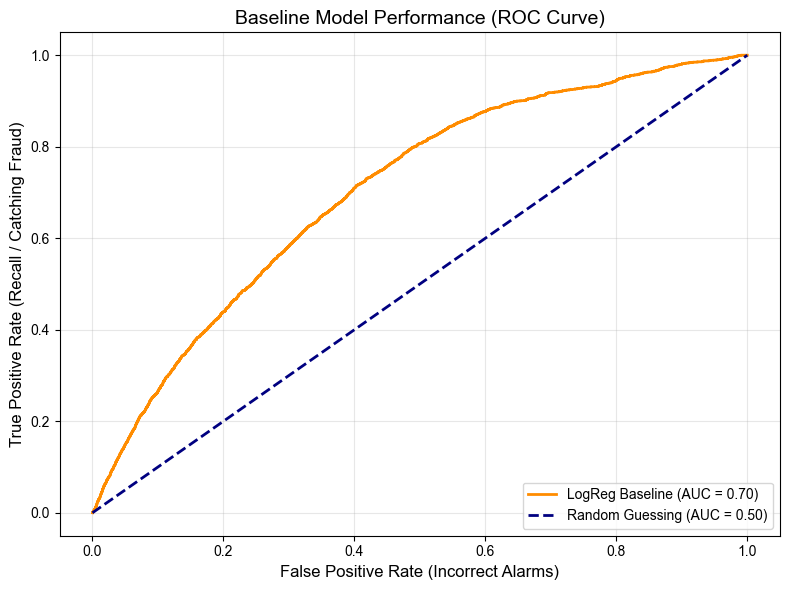

In [104]:
fpr, tpr, _ = roc_curve(y_val, val_probs_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'LogReg Baseline (AUC = {auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.title('Baseline Model Performance (ROC Curve)', fontsize=14)
plt.xlabel('False Positive Rate (Incorrect Alarms)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Catching Fraud)', fontsize=12)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Train XGBoost

In [57]:
xgb_base = XGBClassifier(
    scale_pos_weight=17, 
    tree_method='hist', 
    random_state=42,
    n_jobs=-1
)


param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


xgb_search = RandomizedSearchCV(
    xgb_base, 
    param_distributions=param_dist, 
    n_iter=10, 
    scoring='recall', 
    cv=3, 
    verbose=1,
    random_state=42
)


xgb_search.fit(X_sub_processed, y_sub)
best_model = xgb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [59]:
print(xgb_search.best_params_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [60]:
print(f"Best Search AUC: {xgb_search.best_score_:.4f}")

Best Search AUC: 0.7562


In [61]:
val_probs = best_model.predict_proba(X_val_processed)[:, 1]

threshold = 0.5
val_preds = (val_probs >= threshold).astype(int)

print(f"XGBoost Validation AUC: {roc_auc_score(y_val, val_probs):.4f}")
print(f"XGBoost Validation Recall: {recall_score(y_val, val_preds):.4f}")

XGBoost Validation AUC: 0.7556
XGBoost Validation Recall: 0.7637


In [62]:
print(f"\n--- Results at Threshold {threshold} ---")
print(f"Recall: {recall_score(y_val, val_preds):.4f}")
print(f"Precision: {precision_score(y_val, val_preds):.4f}")
print("\nFull Report:")
print(classification_report(y_val, val_preds))


--- Results at Threshold 0.5 ---
Recall: 0.7637
Precision: 0.1035

Full Report:
              precision    recall  f1-score   support

         0.0       0.98      0.61      0.75     42216
         1.0       0.10      0.76      0.18      2497

    accuracy                           0.62     44713
   macro avg       0.54      0.69      0.47     44713
weighted avg       0.93      0.62      0.72     44713



Text(50.722222222222214, 0.5, 'Actual')

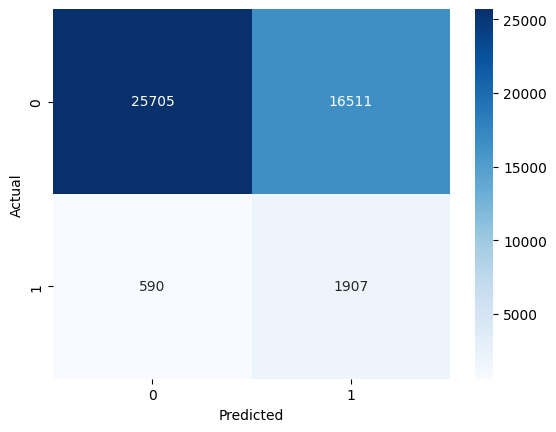

In [63]:
cm_05 = confusion_matrix(y_val, val_preds)

sns.heatmap(cm_05, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [64]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (val_probs >= t).astype(int)
    r = recall_score(y_val, preds)
    p = precision_score(y_val, preds)
    print(f"Threshold {t:.1f} | Recall: {r:.4f} | Precision: {p:.4f}")

Threshold 0.3 | Recall: 0.9375 | Precision: 0.0777
Threshold 0.4 | Recall: 0.8851 | Precision: 0.0860
Threshold 0.5 | Recall: 0.7637 | Precision: 0.1035
Threshold 0.6 | Recall: 0.5166 | Precision: 0.1356
Threshold 0.7 | Recall: 0.2391 | Precision: 0.1989


Precision - The probability that a flagged customer is actually a thief.

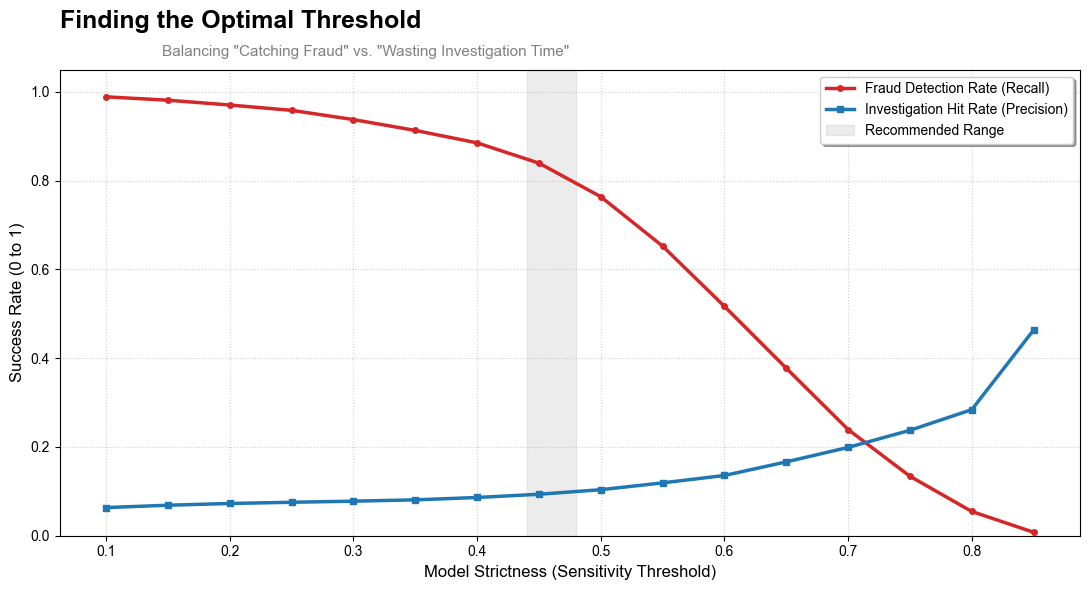

In [108]:
plt.figure(figsize=(11, 6))

plt.plot(threshold_range, auto_recalls, marker='o', markersize=4,
         label='Fraud Detection Rate (Recall)', color='#d62728', linewidth=2.5)
plt.plot(threshold_range, auto_precisions, marker='s', markersize=4,
         label='Investigation Hit Rate (Precision)', color='#1f77b4', linewidth=2.5)

plt.axvspan(0.44, 0.48, color='gray', alpha=0.15, label='Recommended Range')

plt.title('Finding the Optimal Threshold', fontsize=18, fontweight='bold', loc='left', pad=30)
plt.text(0.1, 1.03, 'Balancing "Catching Fraud" vs. "Wasting Investigation Time"', 
         transform=plt.gca().transAxes, fontsize=11, color='gray')

plt.xlabel('Model Strictness (Sensitivity Threshold)', fontsize=12)
plt.ylabel('Success Rate (0 to 1)', fontsize=12)

plt.legend(frameon=True, shadow=True, facecolor='white', loc='upper right', fontsize=10)

plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0, 1.05) 
plt.tight_layout()

plt.savefig('fraud_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
client_thresholds = np.arange(0.40, 0.51, 0.01)

results = []

for t in client_thresholds:
    preds = (val_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()
    
    results.append({
        'Threshold': f"{t:.2f}",
        'Recall (%)': f"{recall_score(y_val, preds)*100:.1f}%",
        'Precision (%)': f"{precision_score(y_val, preds)*100:.1f}%",
        'Thieves Caught': tp,
        'Thieves Missed': fn,
        'Innocent Flagged': fp,
        'Innocent Cleared': tn
    })

decision_table = pd.DataFrame(results)

print("--- CLIENT DECISION MATRIX ---")
print(decision_table.to_string(index=False))

--- CLIENT DECISION MATRIX ---
Threshold Recall (%) Precision (%)  Thieves Caught  Thieves Missed  Innocent Flagged  Innocent Cleared
     0.40      88.5%          8.6%            2210             287             23487             18729
     0.41      87.7%          8.7%            2189             308             22913             19303
     0.42      86.5%          8.8%            2160             337             22299             19917
     0.43      85.7%          9.0%            2140             357             21718             20498
     0.44      85.0%          9.1%            2123             374             21085             21131
     0.45      83.9%          9.3%            2096             401             20383             21833
     0.46      82.3%          9.4%            2055             442             19702             22514
     0.47      81.2%          9.7%            2027             470             18964             23252
     0.48      79.5%          9.8%        

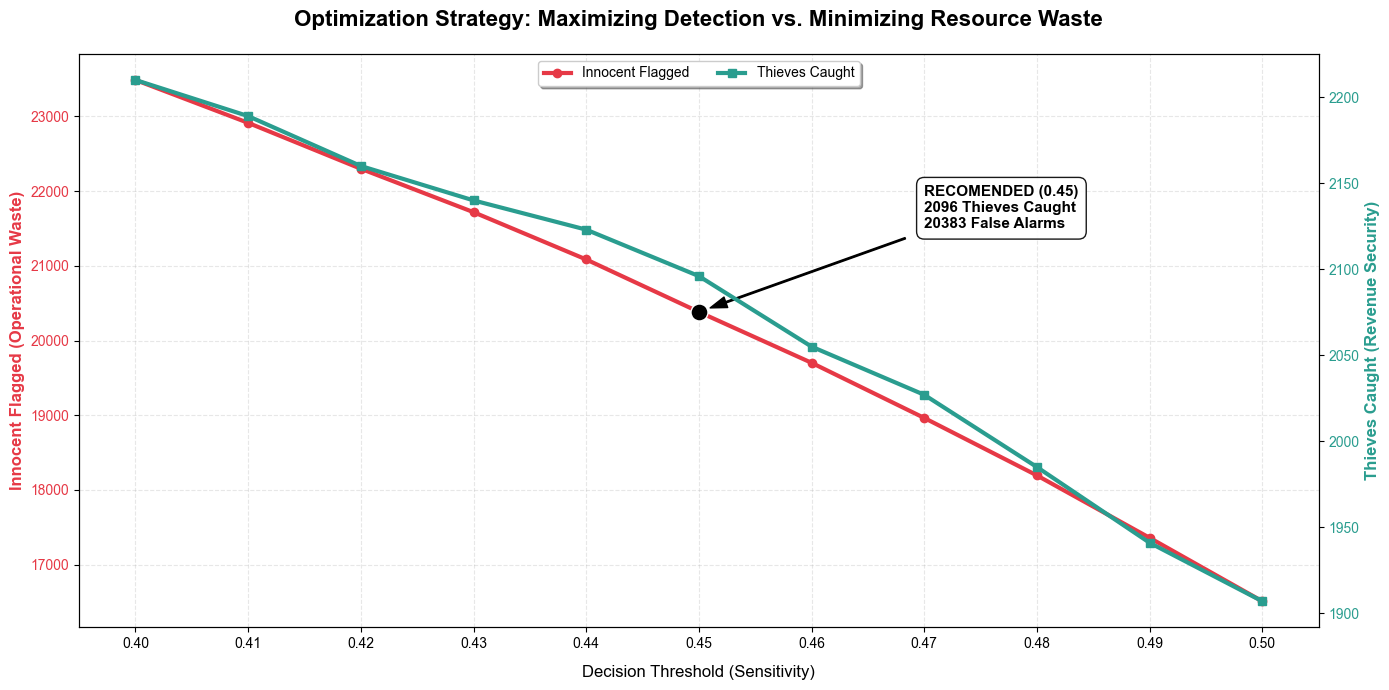

In [109]:
thresholds = [0.40, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.50]
thieves_caught = [2210, 2189, 2160, 2140, 2123, 2096, 2055, 2027, 1985, 1941, 1907]
innocent_flagged = [23487, 22913, 22299, 21718, 21085, 20383, 19702, 18964, 18195, 17360, 16511]

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)
plt.rcParams['font.sans-serif'] = 'Arial'

color_waste = '#e63946'
ax1.set_xlabel('Decision Threshold (Sensitivity)', fontsize=12, labelpad=10)
ax1.set_ylabel('Innocent Flagged (Operational Waste)', color=color_waste, fontsize=12, fontweight='bold')
ax1.plot(thresholds, innocent_flagged, color=color_waste, marker='o', linewidth=3, label='Innocent Flagged')
ax1.tick_params(axis='y', labelcolor=color_waste)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
color_security = '#2a9d8f' 
ax2.set_ylabel('Thieves Caught (Revenue Security)', color=color_security, fontsize=12, fontweight='bold')
ax2.plot(thresholds, thieves_caught, color=color_security, marker='s', linewidth=3, label='Thieves Caught')
ax2.tick_params(axis='y', labelcolor=color_security)

rec_t = 0.45
rec_tp = 2096
rec_fp = 20383

ax1.scatter(rec_t, rec_fp, color='black', s=150, zorder=5, edgecolor='white')
ax1.annotate(f'RECOMENDED (0.45)\n{rec_tp} Thieves Caught\n{rec_fp} False Alarms', 
             xy=(rec_t, rec_fp), xytext=(0.47, 21500),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11, fontweight='bold', bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.9))

plt.title('Optimization Strategy: Maximizing Detection vs. Minimizing Resource Waste', fontsize=16, pad=20, fontweight='bold')
plt.xticks(thresholds)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', frameon=True, shadow=True, ncol=2)

plt.tight_layout()

plt.savefig('optimization_strategy.png', dpi=300, bbox_inches='tight')
plt.show()

In [73]:
def calculate_marginal_price(df, tp_col='TP', fp_col='FP', threshold_col='Threshold'):
    """
    Standardizes the calculation of the "Price" (Marginal Cost).
    
    Formula: (Change in Innocent People) / (Change in Thieves Caught)
    """
    # Sort by threshold descending (Relaxed to Stricter)
    df = df.sort_values(by=threshold_col, ascending=False).reset_index(drop=True)
    
    # Calculate the differences (deltas) between rows
    df['extra_innocents'] = df[fp_col].diff()
    df['extra_thieves'] = df[tp_col].diff()
    
    # Calculate the "Price" (Marginal Cost)
    # How many extra innocents per 1 extra thief?
    df['price_per_thief'] = df['extra_innocents'] / df['extra_thieves']
    
    return df


data = {
    'Threshold': [0.50, 0.48, 0.45, 0.42, 0.40],
    'TP': [1907, 1985, 2096, 2160, 2210],    # Thieves Caught
    'FP': [16511, 18195, 20383, 22299, 23487] # Innocent Flagged
}

df_results = pd.DataFrame(data)
df_analyzed = calculate_marginal_price(df_results)

# Displaying the "Price Tags" for each strategic jump
print("Strategic Jump Analysis:")
for i in range(1, len(df_analyzed)):
    row = df_analyzed.iloc[i]
    prev_thresh = df_analyzed.iloc[i-1]['Threshold']
    curr_thresh = row['Threshold']
    
    print(f"Jump {prev_thresh} -> {curr_thresh}:")
    print(f"  - Extra Thieves Caught: {row['extra_thieves']:.0f}")
    print(f"  - Extra Innocents Flagged: {row['extra_innocents']:.0f}")
    print(f"  - Price: {row['price_per_thief']:.1f} innocents per thief\n")

Strategic Jump Analysis:
Jump 0.5 -> 0.48:
  - Extra Thieves Caught: 78
  - Extra Innocents Flagged: 1684
  - Price: 21.6 innocents per thief

Jump 0.48 -> 0.45:
  - Extra Thieves Caught: 111
  - Extra Innocents Flagged: 2188
  - Price: 19.7 innocents per thief

Jump 0.45 -> 0.42:
  - Extra Thieves Caught: 64
  - Extra Innocents Flagged: 1916
  - Price: 29.9 innocents per thief

Jump 0.42 -> 0.4:
  - Extra Thieves Caught: 50
  - Extra Innocents Flagged: 1188
  - Price: 23.8 innocents per thief



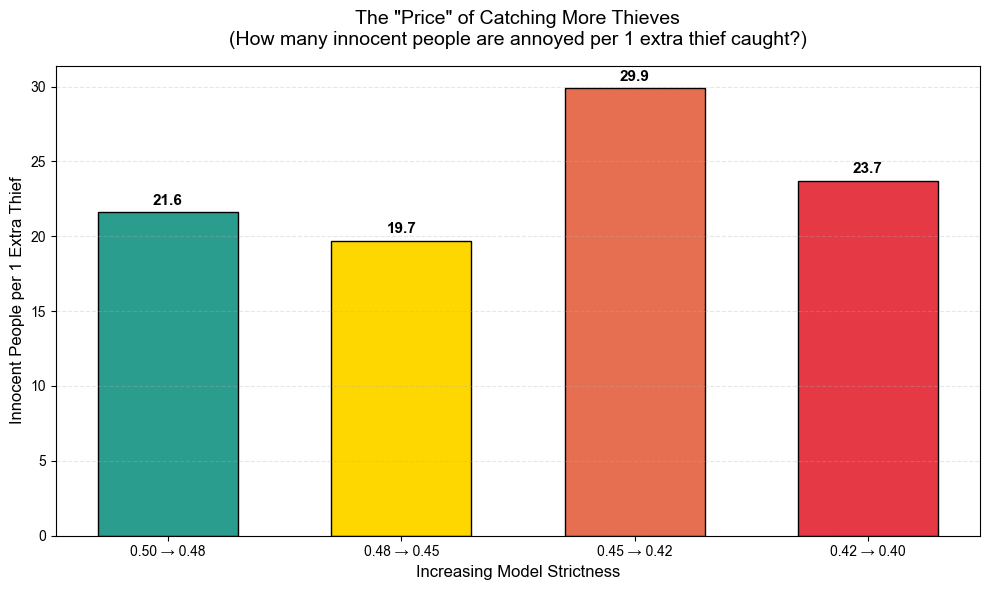

In [113]:
# Exact calculations based on your matrix screenshot
labels = ['0.50 → 0.48', '0.48 → 0.45', '0.45 → 0.42', '0.42 → 0.40']
prices = [21.6, 19.7, 29.9, 23.7] 

plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = 'Arial'

colors = ['#2a9d8f', '#FFD700', '#e76f51', '#e63946'] 

bars = plt.bar(labels, prices, color=colors, edgecolor='black', width=0.6)

plt.title('The "Price" of Catching More Thieves\n(How many innocent people are annoyed per 1 extra thief caught?)', fontsize=14, pad=15)
plt.ylabel('Innocent People per 1 Extra Thief', fontsize=12)
plt.xlabel('Increasing Model Strictness', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('model_strictness.png', dpi=300, bbox_inches='tight')
plt.show()

### Optimal Model Threshold

In [115]:
threshold_final = 0.45
val_preds_final = (val_probs >= threshold_final).astype(int)

print(f"\n--- Results at Threshold {threshold_final} ---")
print(f"Recall: {recall_score(y_val, val_preds_final):.4f}")
print(f"Precision: {precision_score(y_val, val_preds_final):.4f}")
print(f"AUC Score: {roc_auc_score(y_val, val_preds_final):.4f}")


print("\nFull Report:")
print(classification_report(y_val, val_preds_final))


--- Results at Threshold 0.45 ---
Recall: 0.8394
Precision: 0.0932
AUC Score: 0.6783

Full Report:
              precision    recall  f1-score   support

         0.0       0.98      0.52      0.68     42216
         1.0       0.09      0.84      0.17      2497

    accuracy                           0.54     44713
   macro avg       0.54      0.68      0.42     44713
weighted avg       0.93      0.54      0.65     44713



Text(50.722222222222214, 0.5, 'Actual')

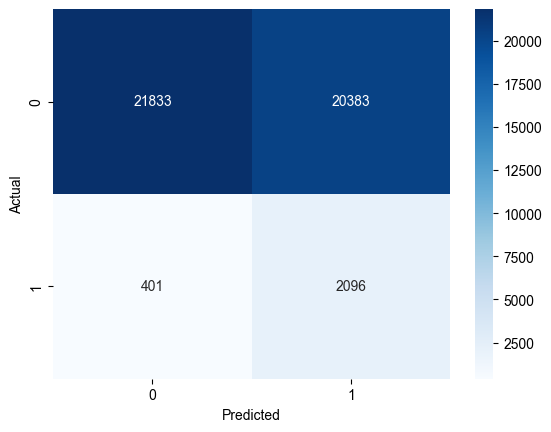

In [76]:
cm_final = confusion_matrix(y_val, val_preds_final)

sns.heatmap(cm_final, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

### Extra Model: Train an Ensemle Method with Random Forest and XGBoost

In [77]:
xgb_best = xgb_search.best_estimator_

rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

ensemble_model = VotingClassifier(
    estimators=[('xgb', xgb_best), ('rf', rf_model)],
    voting='soft',
    weights=[1, 1] # Equal weight to both
)

ensemble_model.fit(X_sub_processed, y_sub)

ens_probs = ensemble_model.predict_proba(X_val_processed)[:, 1]

In [79]:
ens_preds_50 = (ens_probs >= 0.5).astype(int)

ens_preds_30 = (ens_probs >= 0.3).astype(int)

print(f"--- Ensemble (XGB + RF) Performance ---")
print(f"AUC Score: {roc_auc_score(y_val, ens_probs):.4f}")

print(f"\n[Threshold 0.5]")
print(f"Recall:    {recall_score(y_val, ens_preds_50):.4f}")
print(f"Precision: {precision_score(y_val, ens_preds_50):.4f}")

print(f"\n[Threshold 0.3]")
print(f"Recall:    {recall_score(y_val, ens_preds_30):.4f}")
print(f"Precision: {precision_score(y_val, ens_preds_30):.4f}")

print("\nFull Report for Threshold 0.3:")
print(classification_report(y_val, ens_preds_30))

--- Ensemble (XGB + RF) Performance ---
AUC Score: 0.7504

[Threshold 0.5]
Recall:    0.7068
Precision: 0.1079

[Threshold 0.3]
Recall:    0.9267
Precision: 0.0789

Full Report for Threshold 0.3:
              precision    recall  f1-score   support

         0.0       0.99      0.36      0.53     42216
         1.0       0.08      0.93      0.15      2497

    accuracy                           0.39     44713
   macro avg       0.53      0.64      0.34     44713
weighted avg       0.94      0.39      0.51     44713



## Feature Importance

--- THE TOP 10 FRAUD INDICATORS (BY GAIN) ---
                 Feature  Importance
Consommation Level 1 Sum    0.131396
Consommation Level 3 Max    0.104705
              Calc Index    0.080244
      Transactions Count    0.062121
Consommation Level 3 Std    0.048799
Consommation Level 2 Max    0.042022
Consommation Level 1 Min    0.034085
Consommation Level 3 Sum    0.032969
Consommation Level 4 Max    0.032248
Consommation Level 4 Sum    0.026161


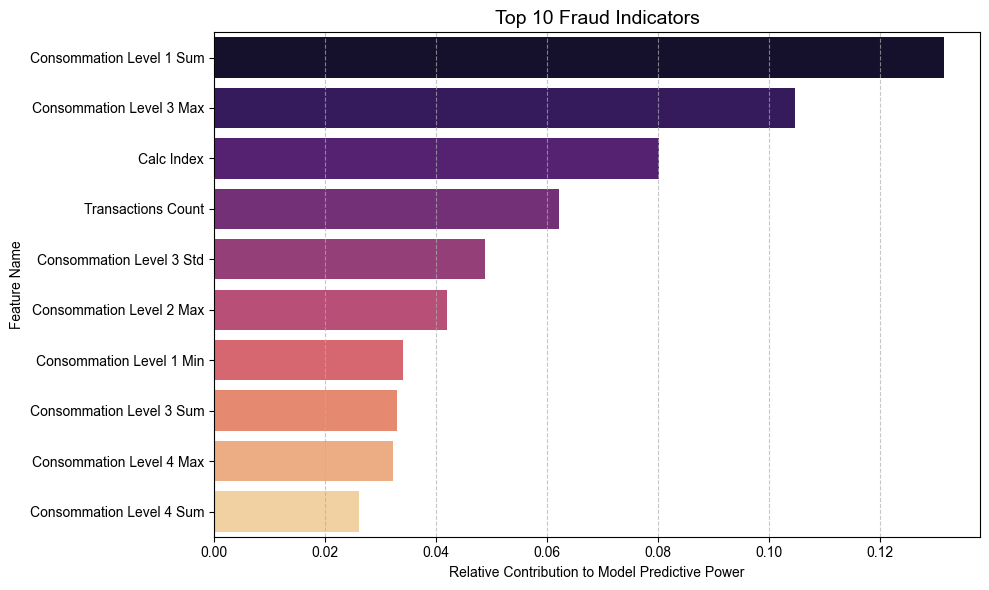

In [114]:
names = processor.get_feature_names_out()
scores = best_model.feature_importances_

importance_df = pd.DataFrame({'Feature': names, 'Importance': scores})

importance_df['Feature'] = (
    importance_df['Feature']
    .str.split('__').str[-1]      
    .str.replace('_', ' ')        
    .str.title()                  
)

top_10 = importance_df.sort_values(by='Importance', ascending=False).head(10)

print("--- THE TOP 10 FRAUD INDICATORS (BY GAIN) ---")
print(top_10.to_string(index=False))

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_10, 
    palette='magma'
)

plt.title('Top 10 Fraud Indicators', fontsize=14)
plt.xlabel('Relative Contribution to Model Predictive Power')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig('feature_imp.png', dpi=300, bbox_inches='tight')
plt.show()

## Make Predictions on test set based on final XGBoost Model

In [100]:
test_probs = best_model.predict_proba(X_test_processed)[:, 1]

final_preds = (test_probs >= 0.45).astype(int)


test_predictions = pd.DataFrame({
    'client_id': test_combined['client_id'], 
    'target': final_preds
})

test_predictions.to_csv('STEG_Final_Submission.csv', index=False)